In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rockinbrock/spy-1-minute-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'spy-1-minute-data' dataset.
Path to dataset files: /kaggle/input/spy-1-minute-data


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv(path + "/spy_1min_2008_2021_cleaned.csv", parse_dates=['date'])
df = df.sort_values('date')
df.head()

,date,open,high,low,close,volume,barCount,average
0,2008-01-22 07:30:00,126.45,126.82,126.00,126.67,30987,4541,126.283
1,2008-01-22 07:31:00,126.67,127.17,126.39,127.12,20111,3125,126.958
2,2008-01-22 07:32:00,127.10,127.13,126.71,126.78,11979,2074,126.922
3,2008-01-22 07:33:00,126.76,126.90,126.53,126.54,8017,1350,126.675
4,2008-01-22 07:34:00,126.54,127.18,126.54,126.78,11967,1253,126.730


In [ ]:
features = ['open', 'high', 'low', 'close', 'volume', 'barCount', 'average']
data = df[features].values

In [ ]:
data

array([[  126.45 ,   126.82 ,   126.   , ..., 30987.   ,  4541.   ,
          126.283],
       [  126.67 ,   127.17 ,   126.39 , ..., 20111.   ,  3125.   ,
          126.958],
       [  127.1  ,   127.13 ,   126.71 , ..., 11979.   ,  2074.   ,
          126.922],
       ...,
       [  418.64 ,   418.79 ,   418.63 , ...,  6912.   ,  2868.   ,
          418.744],
       [  418.79 ,   418.83 ,   418.71 , ...,  7891.   ,  3862.   ,
          418.784],
       [  418.76 ,   419.21 ,   418.76 , ..., 18343.   ,  8005.   ,
          419.014]])

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [ ]:
scaled_data

array([[0.16781219, 0.16864675, 0.16671384, ..., 0.09353662, 0.15014052,
        0.16732837],
       [0.16843445, 0.1696368 , 0.16781772, ..., 0.06070659, 0.10332286,
        0.16923847],
       [0.16965069, 0.16952365, 0.16872346, ..., 0.03615953, 0.06857332,
        0.1691366 ],
       ...,
       [0.99425824, 0.99454062, 0.99499009, ..., 0.0208644 , 0.09482559,
        0.99493184],
       [0.99468251, 0.99465377, 0.99521653, ..., 0.02381959, 0.12769053,
        0.99504504],
       [0.99459765, 0.99572867, 0.99535805, ..., 0.05536975, 0.26467185,
        0.99569589]])

In [ ]:
def sequences(data, seq_length=100):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i + seq_length])
        y.append(data[i + seq_length, :])  # predict "close" -> can change as necessary
    return np.array(x), np.array(y)

In [ ]:
SEQ_LEN = 60
x, y = sequences(scaled_data, SEQ_LEN)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, shuffle=False
)

In [ ]:
y.shape

(2070774, 7)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,767 (210.03 KB)

 Trainable params: 53,767 (210.03 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
23297/23297 ━━━━━━━━━━━━━━━━━━━━ 174s 7ms/step - loss: 2.3032e-04 - val_loss: 3.7345e-05
Epoch 2/10
23297/23297 ━━━━━━━━━━━━━━━━━━━━ 171s 7ms/step - loss: 4.6839e-05 - val_loss: 3.3370e-05
Epoch 3/10
23297/23297 ━━━━━━━━━━━━━━━━━━━━ 172s 7ms/step - loss: 4.5910e-05 - val_loss: 3.3586e-05
Epoch 4/10
23297/23297 ━━━━━━━━━━━━━━━━━━━━ 171s 7ms/step - loss: 4.5494e-05 - val_loss: 3.1562e-05
Epoch 5/10
23297/23297 ━━━━━━━━━━━━━━━━━━━━ 172s 7ms/step - loss: 4.5265e-05 - val_loss: 3.2696e-05
Epoch 6/10
23297/23297 ━━━━━━━━━━━━━━━━━━━━ 171s 7ms/step - loss: 4.5194e-05 - val_loss: 3.1764e-05
Epoch 7/10
23297/23297 ━━━━━━━━━━━━━━━━━━━━ 172s 7ms/step - loss: 4.5365e-05 - val_loss: 3.7761e-05
Epoch 8/10
23297/23297 ━━━━━━━━━━━━━━━━━━━━ 173s 7ms/step - loss: 4.4946e-05 - val_loss: 4.1333e-05
Epoch 9/10
23297/23297 ━━━━━━━━━━━━━━━━━━━━ 172s 7ms/step - loss: 4.4980e-05 - val_loss: 3.0511e-05
Epoch 10/10
23297/23297 ━━━━━━━━━━━━━━━━━━━━ 172s 7ms/step - loss: 4.5087e-05 - val_loss: 2.9474e-05

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


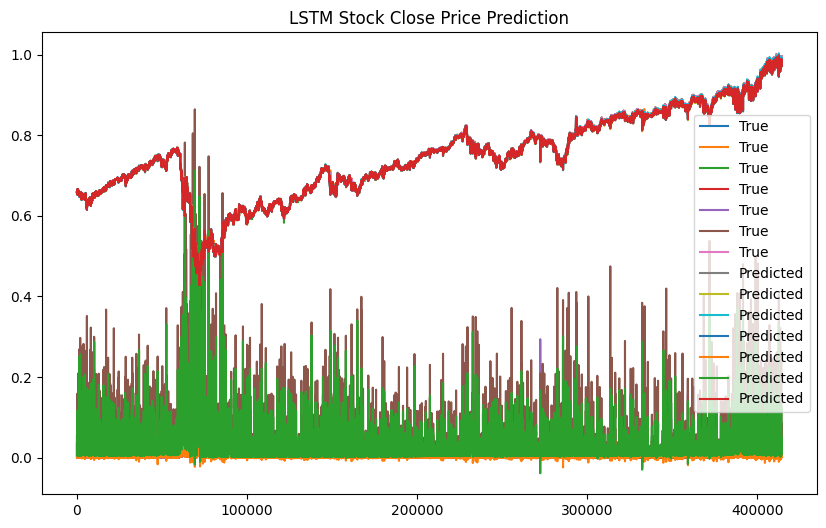

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, x.shape[2])),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(7)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

#Train model
history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    verbose=1
)

#Evaluate
predictions = model.predict(x_test)
plt.figure(figsize=(10,6))
plt.plot(y_test, label='True')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title("LSTM Stock Close Price Prediction")
plt.show()

In [ ]:
model.save('LSTM_MODEL.h5')

In [ ]:
model.save('LSTM_MODEL.keras')
model.save('LSTM_MODEL.h5')

In [ ]:
close_index = features.index('close')

# Create empty arrays for inverse transformation
predicted_actual = []
true_actual = []

for pred, true_val in zip(predictions, y_test):
    # Build dummy row filled with zeros
    dummy_pred = np.zeros(len(features))
    dummy_true = np.zeros(len(features))

    # Put the predicted close in the correct column
    dummy_pred[close_index] = pred
    dummy_true[close_index] = true_val

    # Inverse transform both
    inv_pred = scaler.inverse_transform([dummy_pred])[0][close_index]
    inv_true = scaler.inverse_transform([dummy_true])[0][close_index]

    predicted_actual.append(inv_pred)
    true_actual.append(inv_true)

predicted_actual = np.array(predicted_actual)
true_actual = np.array(true_actual)

ValueError: setting an array element with a sequence.

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(true_actual, label='True Close Price')
plt.plot(predicted_actual, label='Predicted Close Price')
plt.legend()
plt.title("Actual vs Predicted Close Prices")
plt.show()

In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model('/content/gdrive/My Drive/my_models/LSTM_MODEL.h5')

In [ ]:
SEQ_LEN = 60
FORECAST_LEN = 7200  # 120 hours at 1-minute intervals
feature_count = 7    # only the first 7 features are predicted

# === STEP 1: Choose starting point (e.g., beginning of test data) ===
start_idx = len(scaled_data) - (FORECAST_LEN + SEQ_LEN)
current_seq = scaled_data[start_idx:start_idx + SEQ_LEN].copy()  # shape (60, n_features)

# === STEP 2: Predict recursively ===
forecast_scaled = []

for _ in range(FORECAST_LEN):
    input_seq = np.expand_dims(current_seq, axis=0)  # shape (1, 60, n_features)
    pred = model.predict(input_seq, verbose=0)[0]    # shape (7,)

    # create full-length vector (fill time features with zeros)
    new_point = np.zeros(current_seq.shape[1])
    new_point[:feature_count] = pred

    # append prediction to sequence and drop oldest step
    current_seq = np.vstack([current_seq[1:], new_point])

    # store prediction
    forecast_scaled.append(new_point[:feature_count])

forecast_scaled = np.array(forecast_scaled)

# === STEP 3: Inverse transform back to actual values ===
forecast_actual = []
actual_actual = []

for i in range(FORECAST_LEN):
    dummy_pred = np.zeros(len(features))
    dummy_true = np.zeros(len(features))

    dummy_pred[:feature_count] = forecast_scaled[i]
    dummy_true[:feature_count] = scaled_data[start_idx + SEQ_LEN + i][:feature_count]

    inv_pred = scaler.inverse_transform([dummy_pred])[0][:feature_count]
    inv_true = scaler.inverse_transform([dummy_true])[0][:feature_count]

    forecast_actual.append(inv_pred)
    actual_actual.append(inv_true)

forecast_actual = np.array(forecast_actual)
actual_actual = np.array(actual_actual)

# === STEP 4: Compare & Plot Each Feature ===
feature_names = features

for i, name in enumerate(feature_names):
    plt.figure(figsize=(10,5))
    plt.plot(actual_actual[:, i], label='Actual')
    plt.plot(forecast_actual[:, i], label='Predicted', alpha=0.8)
    plt.title(f"{name} — 120 Hour Forecast")
    plt.legend()
    plt.show()
